# Task
Analyze the "medical_cost_personal_dataset.csv" dataset, perform exploratory data analysis, preprocess categorical features, train a Linear Regression model to predict insurance charges, and evaluate the model's performance. Summarize the key factors influencing insurance charges based on the analysis.

## Load Dataset



In [1]:
import pandas as pd

df = pd.read_csv('/content/medical_cost_personal_dataset.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Basic Data Exploration


In [2]:
print("DataFrame shape:", df.shape)
print("\nDataFrame Info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame shape: (1338, 7)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Data Preprocessing - Categorical Encoding



In [3]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print("DataFrame after One-Hot Encoding:")
df.head()

DataFrame after One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Rationale for One-Hot Encoding


## Exploratory Data Analysis (EDA)




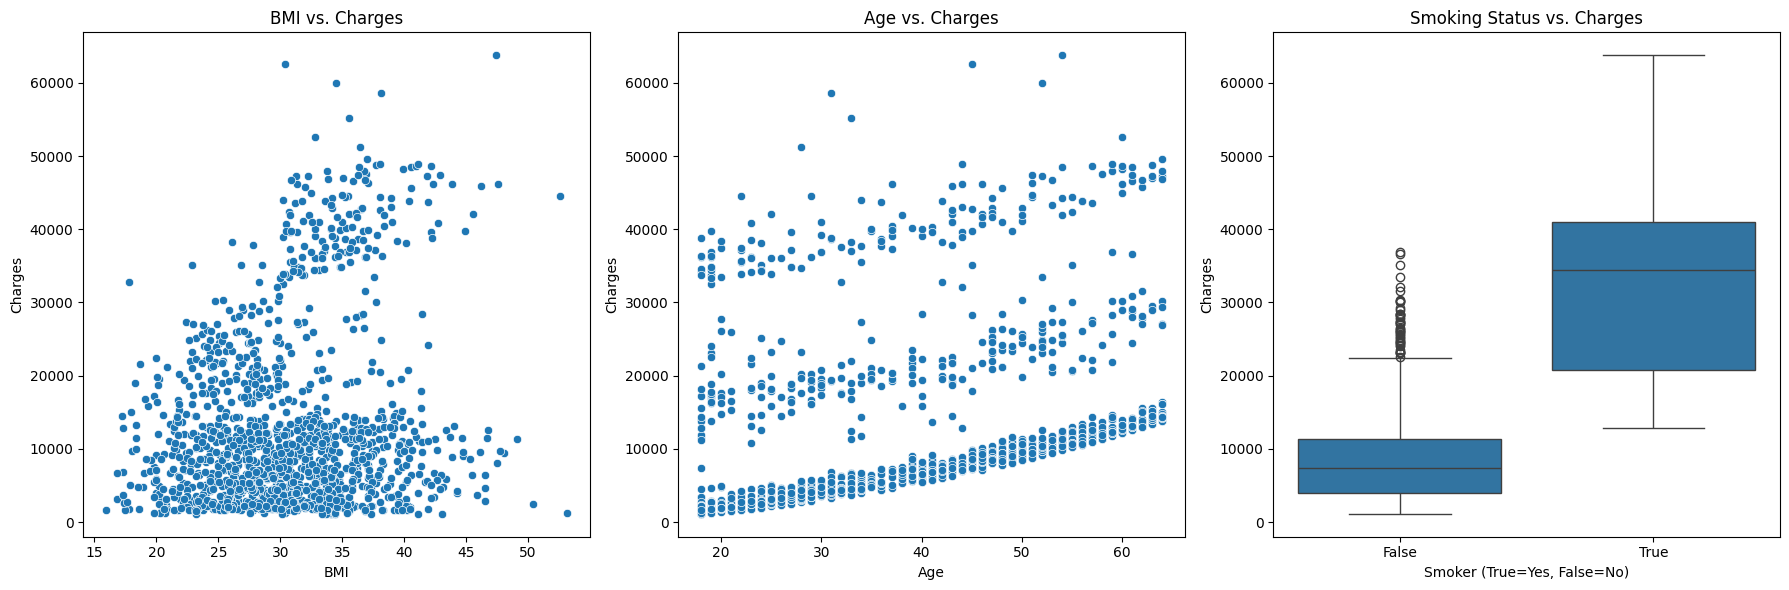

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

# BMI vs. charges
plt.subplot(1, 3, 1)
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs. Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')

# Age vs. charges
plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs. Charges')
plt.xlabel('Age')
plt.ylabel('Charges')

# Smoking status vs. charges (using 'smoker_yes' which is now a boolean/binary column)
plt.subplot(1, 3, 3)
sns.boxplot(x='smoker_yes', y='charges', data=df)
plt.title('Smoking Status vs. Charges')
plt.xlabel('Smoker (True=Yes, False=No)')
plt.ylabel('Charges')

plt.tight_layout()
plt.show()

## Correlation Analysis



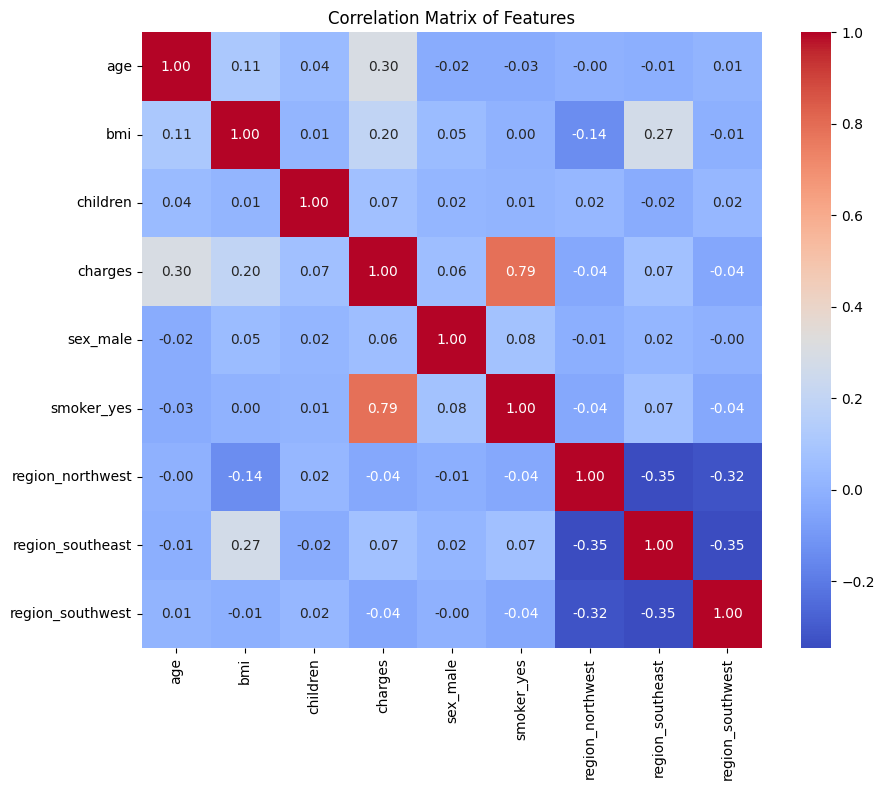

In [5]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

## Split Data


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


## Train Linear Regression Model



In [7]:
from sklearn.linear_model import LinearRegression

# Instantiate the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Make Predictions




In [8]:
y_pred = model.predict(X_test)

print("Predictions on the test set:")
print(y_pred[:5])

Predictions on the test set:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


## Evaluate Model Performance



In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared (R2 Score): 0.78


### Analysis of Model Performance

The evaluation metrics provide insights into how well our Linear Regression model performs in predicting medical insurance charges:

*   **Mean Absolute Error (MAE): 4181.19**
    *   This indicates that, on average, our model's predictions are off by approximately $4181.19 from the actual charges. This value should be considered in the context of the range of 'charges' in the dataset.

*   **Mean Squared Error (MSE): 33596915.85**
    *   MSE penalizes larger errors more heavily. While the value itself is large, it's more interpretable through its square root.

*   **Root Mean Squared Error (RMSE): 5796.28**
    *   RMSE is in the same units as the target variable (charges) and represents the standard deviation of the residuals (prediction errors). An RMSE of $5796.28 means that the typical error magnitude is about this amount.

*   **R-squared (R2 Score): 0.78**
    *   The R2 score indicates the proportion of the variance in the dependent variable (charges) that is predictable from the independent variables. An R2 score of 0.78 means that approximately 78% of the variance in insurance charges can be explained by our model's features. This suggests a reasonably good fit, but there is still about 22% of the variance that the model does not explain.

In summary, the model shows a decent ability to predict insurance charges, explaining a significant portion of the variance. However, there's still room for improvement, as indicated by the MAE and RMSE values, which are significant compared to the overall range of charges.

In [10]:
feature_names = X_train.columns
coefficients = model.coef_

# Create a DataFrame for better readability
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see most influential factors
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Model Coefficients (sorted by absolute value):")
print(coefficients_df)


Model Coefficients (sorted by absolute value):
            Feature   Coefficient  Abs_Coefficient
4        smoker_yes  23651.128856     23651.128856
7  region_southwest   -809.799354       809.799354
6  region_southeast   -657.864297       657.864297
2          children    425.278784       425.278784
5  region_northwest   -370.677326       370.677326
1               bmi    337.092552       337.092552
0               age    256.975706       256.975706
3          sex_male    -18.591692        18.591692


### Summary of Key Factors Influencing Insurance Charges

Based on the Linear Regression model's coefficients and earlier exploratory data analysis, the most influential factors affecting insurance charges are:

1.  **Smoker Status (`smoker_yes`):** This is by far the most significant factor, with a coefficient of approximately **23,651.13**. This indicates that, all else being equal, being a smoker increases insurance charges by an average of about $23,651. This aligns strongly with the EDA, which showed a clear and substantial difference in charges between smokers and non-smokers, with smokers paying significantly more.

2.  **Age (`age`):** Age has a positive impact on charges, with a coefficient of approximately **256.98**. This suggests that for each additional year of age, insurance charges increase by about $257. This is consistent with the scatter plot of age vs. charges, which showed a general upward trend.

3.  **BMI (`bmi`):** BMI also shows a positive relationship with charges, having a coefficient of approximately **337.09**. This implies that for every one-unit increase in BMI, charges tend to increase by about $337. The scatter plot of BMI vs. charges also indicated a positive correlation, though with more spread.

4.  **Number of Children (`children`):** The number of children has a positive, albeit smaller, impact on charges, with a coefficient of approximately **425.28**. This means each child adds about $425 to the insurance cost.

5.  **Region (`region_southwest`, `region_southeast`, `region_northwest`):** The region variables have smaller, negative coefficients relative to other factors when compared to the baseline region (northeast, which is not explicitly listed because `drop_first=True` was used for one-hot encoding). For instance, living in the southwest region is associated with a decrease of approximately $809.80 in charges compared to the baseline, holding other factors constant. The southeast and northwest regions also show slightly lower charges compared to the northeast. While statistically significant, their impact is less pronounced than smoking status, age, or BMI.

6.  **Sex (`sex_male`):** Sex appears to be the least influential factor in this model, with a very small negative coefficient of approximately **-18.59**. This suggests a negligible difference in charges between males and females, or a slight decrease for males compared to females (the baseline category).

In conclusion, **smoking status** is the predominant driver of insurance costs. **Age** and **BMI** are also significant contributors, where higher values lead to higher charges. The number of **children** has a moderate positive effect, while **regional differences** are present but less impactful than the primary health-related factors. Sex, as modeled, has a minimal influence.

## Summary:

### Q&A
The key factors influencing insurance charges are primarily:
*   **Smoking status:** Being a smoker is by far the most significant factor, increasing insurance charges by approximately \$23,651 compared to non-smokers.
*   **Age:** Each additional year of age increases insurance charges by about \$257.
*   **BMI:** For every one-unit increase in BMI, charges tend to increase by about \$337.
*   **Number of Children:** Each child adds approximately \$425 to the insurance cost.
*   **Region:** Regional differences exist, with living in the southwest, southeast, or northwest generally associated with slightly lower charges compared to the northeast region (e.g., southwest reduces charges by about \$809.80).
*   **Sex:** Sex appears to have a minimal influence, with males having a negligible decrease in charges compared to females (about -\$18.59).

### Data Analysis Key Findings
*   The dataset contains 1338 rows and 7 columns, with no missing values in any feature.
*   Categorical variables ('sex', 'smoker', 'region') were successfully One-Hot Encoded, preventing ordinal assumptions and multicollinearity (`drop_first=True`).
*   Exploratory Data Analysis (EDA) revealed a strong positive relationship between smoking status and insurance charges, with smokers paying significantly more. Positive trends were also observed for age and BMI against charges.
*   Correlation analysis confirmed these relationships, highlighting a strong positive correlation between being a smoker and insurance charges, and moderate positive correlations for age and BMI.
*   A Linear Regression model was trained and evaluated, achieving an R-squared score of 0.78, indicating that 78% of the variance in insurance charges can be explained by the model's features.
*   The model showed a Mean Absolute Error (MAE) of \$4181.19 and a Root Mean Squared Error (RMSE) of \$5796.28, suggesting that predictions are typically off by these amounts.
*   Model coefficients quantitatively confirmed that smoking status (`smoker_yes`) is the most dominant predictor, followed by age, BMI, and the number of children.

### Insights or Next Steps
*   Given the significant impact of smoking on insurance charges, targeted health initiatives aimed at smoking cessation could lead to substantial reductions in healthcare costs for individuals.
*   To potentially improve model accuracy, exploring more advanced regression techniques or incorporating interaction terms between highly influential features (e.g., age and smoking status) could be beneficial.
